In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import svm
from joblib import Parallel, delayed
import os
top_dir =  '/Users/sm6511/Desktop/NIH_Experiment/Bids/Derivatives/'
base = "base"
name = "latency" 
base_path = os.path.join(top_dir, "Processed_Data", "Sliding Window", name)

subjects = [f"S{i:02}" for i in range(1, 21)] 
output_dir = os.path.join('/Users/sm6511/Desktop/NIH_Experiment/Bids/derivatives/Plots')
#output_dir = os.path.join(top_dir, "Plots", "Extras", "test")
time_values = np.arange(-0.18, 0.58 + 0.01, 0.01)

all_decoding = []
for subj in subjects:
    if name == base:
        filename = f"slidingWindow1_peaks_{subj}.npy"
    elif name == "latency":
        filename = f"slidingWindow1_peaks_{subj}_latency.npy"
    filepath = os.path.join(base_path, filename)
    decoding = np.load(filepath)
    all_decoding.append(decoding)
    plt.figure(figsize=(6, 5))
    plt.axhline(y=1/16, color='grey', linestyle='--', label='chance')
    plt.plot(time_values, decoding, color='#6495ED')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Decoding Accuracy')
    plt.title(f"Subject {subj}")
    #plt.savefig(f"{output_dir}/slidingWindow1_plot_{Subject}.png")
    #plt.close()
    #plt.show()

avg_peak = np.mean(all_decoding, axis=0)
sem_peak = np.std(all_decoding, axis=0, ddof=1) / np.sqrt(len(subjects))  # Standard Error


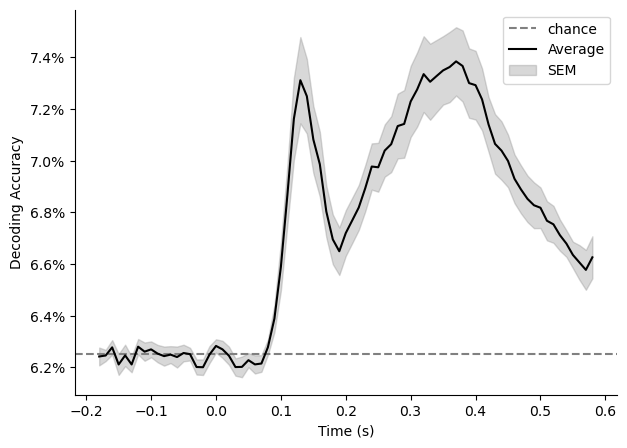

In [30]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Plot average with standard error
plt.figure(figsize=(7, 5))

plt.axhline(y=1/16, linestyle='--', label='chance', color = 'grey')
plt.plot(time_values, avg_peak, label='Average', color = 'black')
plt.fill_between(
    time_values,
    avg_peak - sem_peak,
    avg_peak + sem_peak,
    alpha=0.3,
    label='SEM',
    color = 'grey'
)

plt.xlabel('Time (s)')
plt.ylabel('Decoding Accuracy')
#plt.title("Average Across Subjects")
plt.legend(loc='upper right')


# Axis formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(f"{output_dir}/Figure2aSlidingWindow.png")

editable_dir = os.path.join(output_dir, 'editable')
os.makedirs(editable_dir, exist_ok=True)
base_name = "Figure2aSlidingWindow"

plt.savefig(os.path.join(editable_dir, base_name + '.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(editable_dir, base_name + '.svg'), bbox_inches='tight')

plt.show()


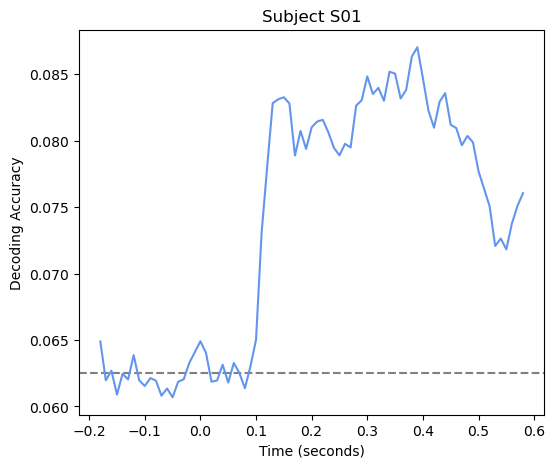

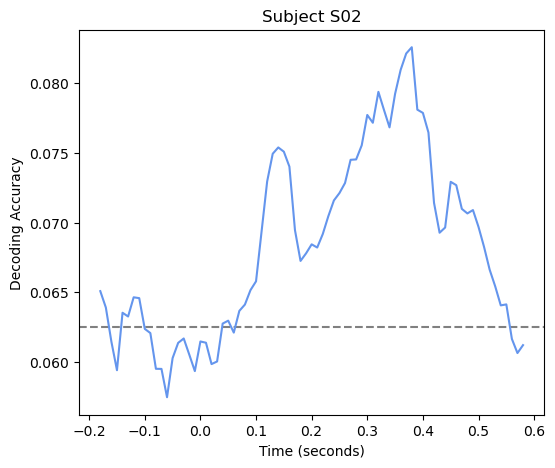

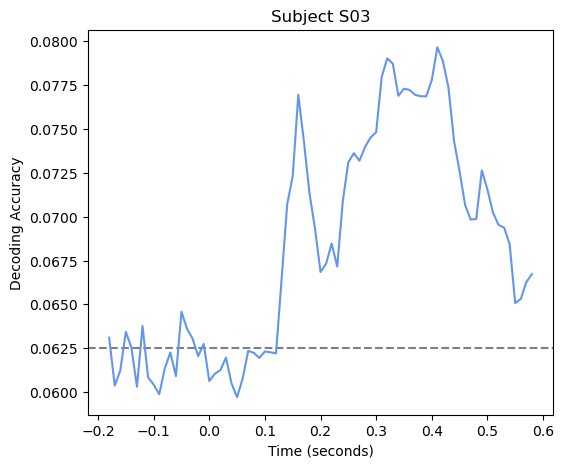

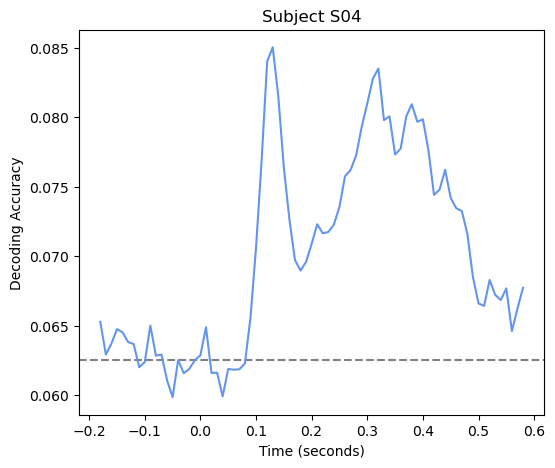

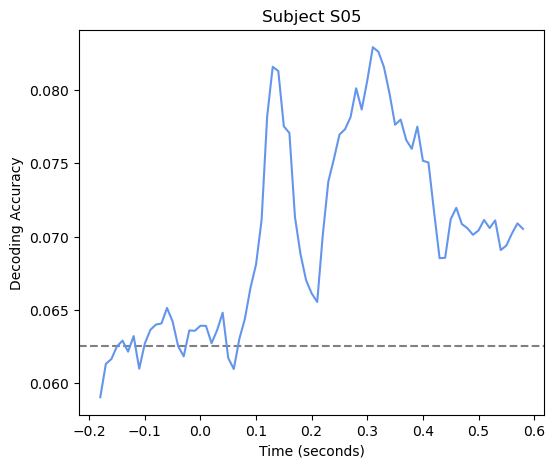

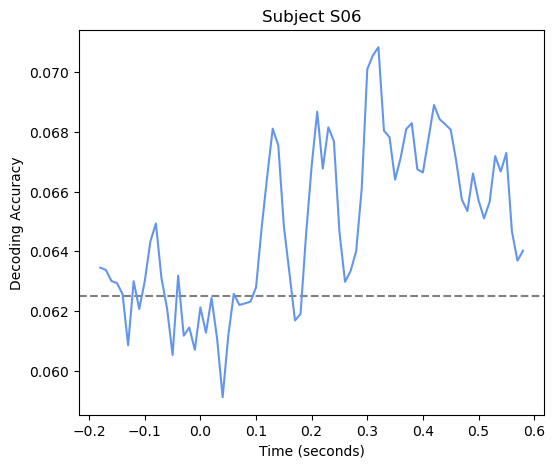

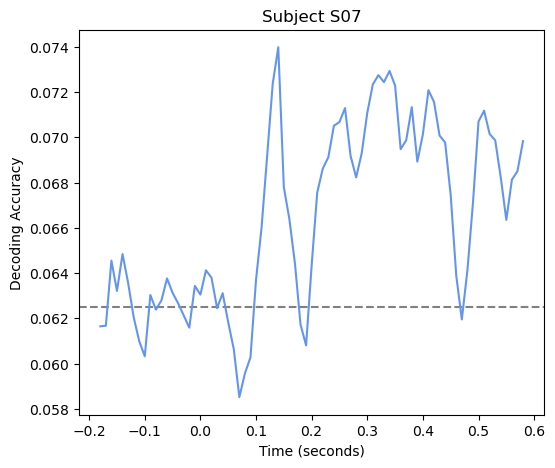

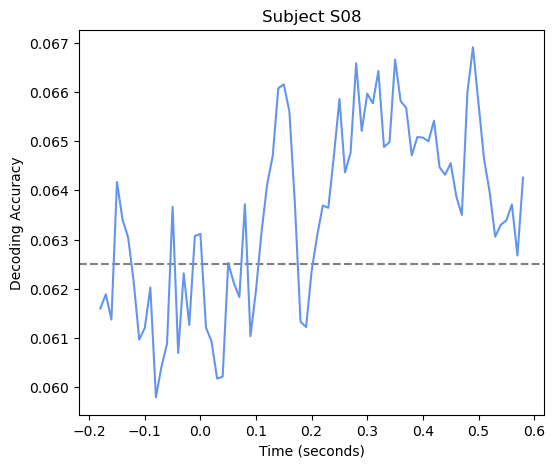

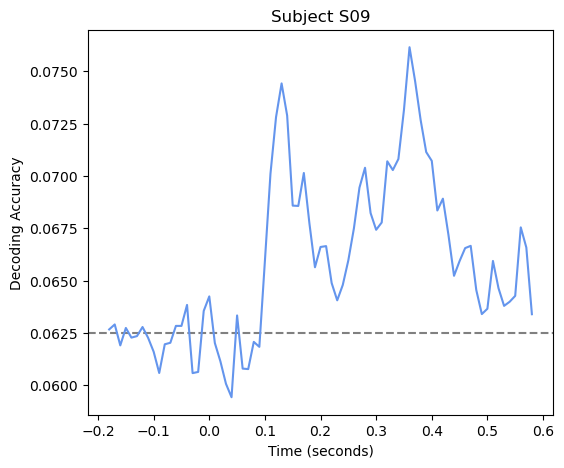

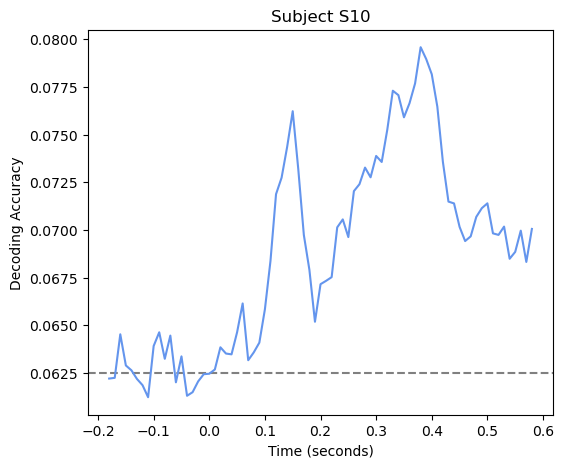

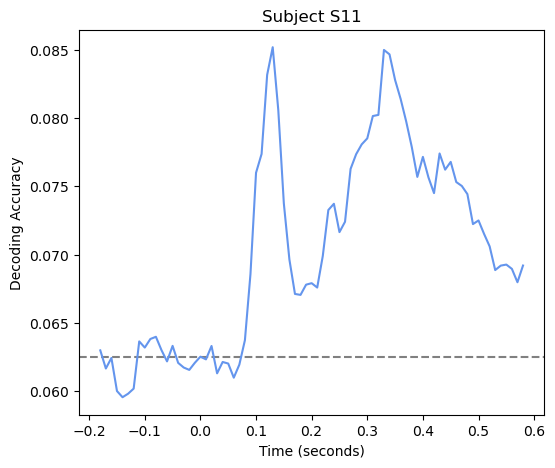

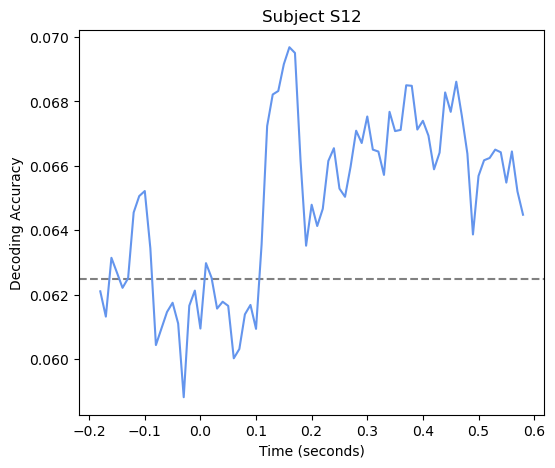

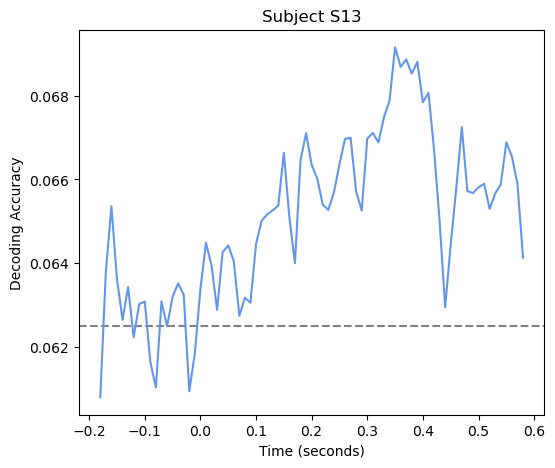

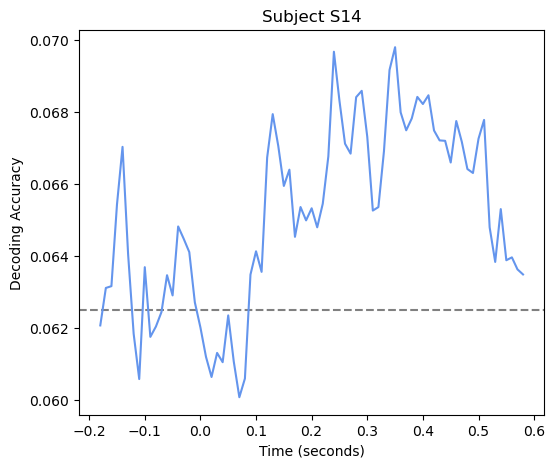

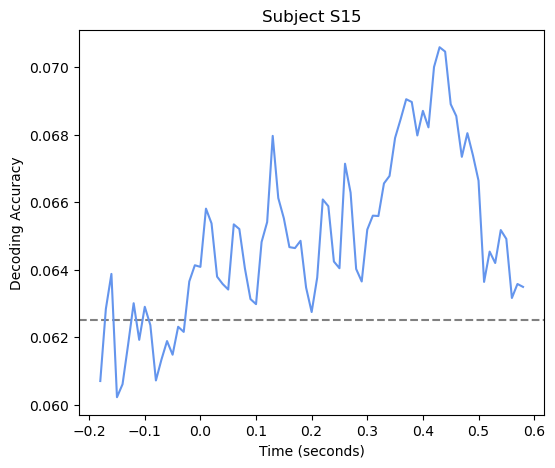

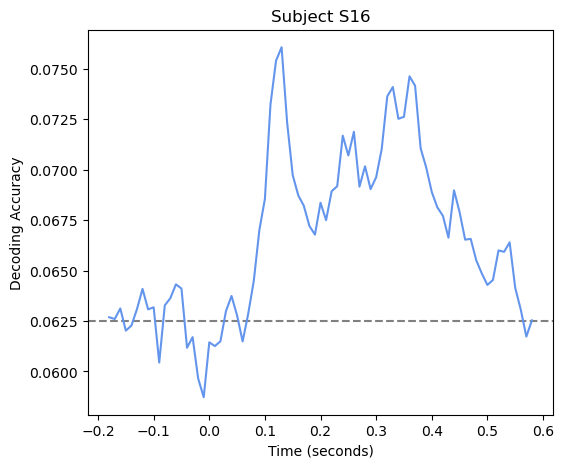

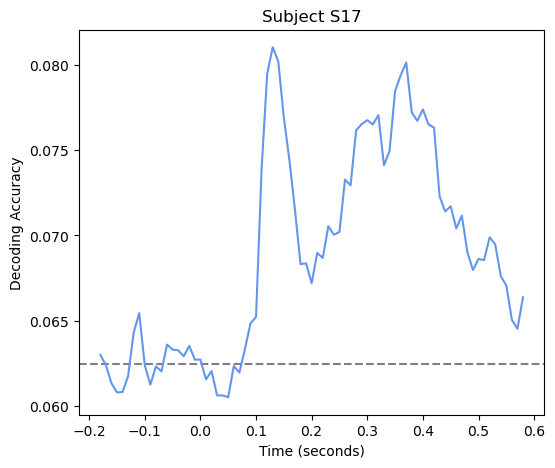

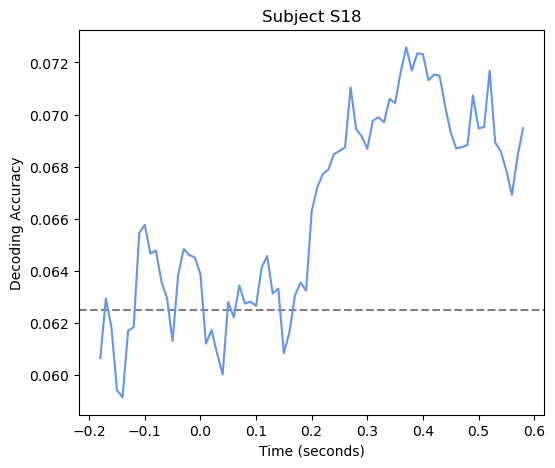

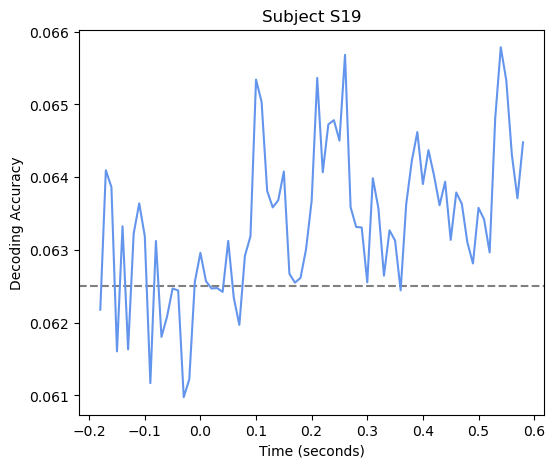

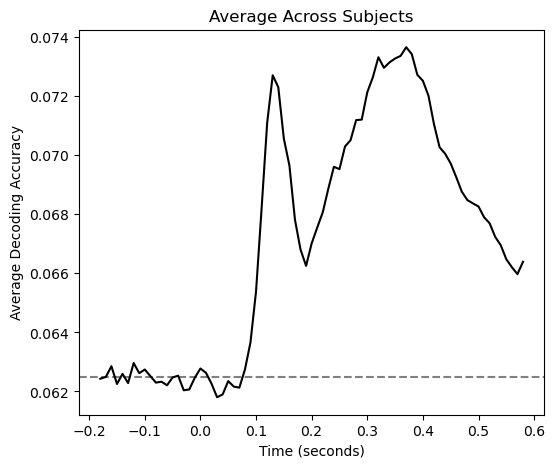

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import svm
from joblib import Parallel, delayed
import os

top_dir =  '/Users/sm6511/Desktop/NIH_Experiment/Bids/Derivatives/'
base_path = os.path.join(top_dir, "Processed_Data", "Sliding Window", "latency")

subjects = [f"S{i:02}" for i in range(1, 20)] 
output_dir = '/System/Volumes/Data/misc/data12/sjapee/Sebastian-OrientationImagery/!Important Data/Sliding Window'
output_dir = os.path.join(top_dir, "Plots", "Extras", "test")
time_values = np.arange(-0.18, 0.58 + 0.01, 0.01)

all_decoding = []
for subj in subjects:
    filename = f"slidingWindow1_peaks_{subj}_latency.npy"
    filepath = os.path.join(base_path, filename)
    decoding = np.load(filepath)
    all_decoding.append(decoding)
    plt.figure(figsize=(6, 5))
    plt.axhline(y=1/16, color='grey', linestyle='--', label='chance')
    plt.plot(time_values, decoding, color='#6495ED')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Decoding Accuracy')
    plt.title(f"Subject {subj}")
    #plt.savefig(f"{output_dir}/slidingWindow1_plot_{Subject}.png")
    #plt.close()
    plt.show()

# Final average plot across processed subjects
avg_peak = np.mean(all_decoding, axis=0)
#np.save(f"{output_dir}/decoding_peaks_avg1.npy", avg_peak)
plt.figure(figsize=(6, 5))
plt.axhline(y=1/16, color='grey', linestyle='--', label='chance')
plt.plot(time_values, avg_peak, color='black')
plt.xlabel('Time (seconds)')
plt.ylabel('Average Decoding Accuracy')
plt.title("Average Across Subjects")
#plt.savefig(f"{output_dir}/slidingWindow1_average.png")
#plt.close()
plt.show()